# Bank Survival Analysis — Customer Churn Timing

## Business Case

Traditional churn classification asks:

> **"Will this customer churn?"**

Survival Analysis asks a richer question:

> **"What is the probability that the customer survives, and when is the churn likely to happen?"**

This notebook builds an end-to-end banking Survival Analysis project using synthetic customer data.

### Objective

Estimate:

1. Customer survival probability over time
2. Churn risk
3. Expected timing of churn
4. Factors associated with churn
5. High-risk customer groups

> Synthetic data is used for education only.

## 1. Survival Analysis Concept

Survival Analysis models the **time until an event occurs**.

```text
Customer joins / observation starts
              ↓
       Customer remains active
              ↓
       ┌──────┴──────┐
       ↓             ↓
    Churn         Still Active
       ↓             ↓
   Event=1       Censored
```

The event can be:

- customer churn,
- loan default,
- account closure,
- first delinquency,
- product cancellation.

### Key difference from classification

Classification:

```text
Churn? → Yes / No
```

Survival Analysis:

```text
Churn?
+
When?
+
Probability of surviving until time t?
```

## 2. Important Terminology

### Event

The event of interest.

Here:

```text
Customer Churn
```

### Duration / Time-to-Event

How long the customer was observed before:

- churn, or
- observation ended.

### Censoring

The event was not observed during the observation window.

Example:

```text
Customer active for 36 months
Observation ends
Customer did not churn
```

We do **not** know whether they would churn later.

This is called **right censoring**.

## 3. Banking Use Cases

### Customer Churn

```text
When will the customer leave?
```

### Loan Default Timing

```text
When might the loan default?
```

### Credit Card Cancellation

```text
How long until card cancellation?
```

### Product Retention

```text
How long will a customer keep a product?
```

### Collection

```text
How long until a delinquency event?
```

Survival analysis is especially useful when **timing matters**, not only whether an event happens.

## 4. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, lifelines for Kaplan-Meier and Cox models, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

df=pd.read_csv("bank_customer_survival_sample.csv")

print("Rows:",len(df))
display(df.head())
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Rows: 3000


,Customer_ID,Age,Tenure_Months,Monthly_Income,Product_Count,Monthly_Transactions,Digital_Engagement,Complaint_Count,Credit_Utilization,Late_Payment_Count,Segment,Observation_Months,Churn_Event,Churn_Label
0,C00001,25,94,26291033,1,18,15,1,0.539379,2,Mass,45.3,0,Active/Censored
1,C00002,55,82,33851961,2,23,87,1,0.798801,1,Mass,60.0,0,Active/Censored
2,C00003,50,112,27047010,2,21,98,1,0.846806,1,Mass,37.3,0,Active/Censored
3,C00004,40,116,25387455,4,20,54,1,0.142273,0,Mass,60.0,0,Active/Censored
4,C00005,40,86,20824887,2,9,25,4,0.831197,1,Mass,19.1,0,Active/Censored


## 5. Dataset Dictionary

Every field is defined — tenure, churn flag, product holdings and demographics. Survival analysis needs a duration column plus an event indicator, so the dictionary clarifies exactly which column plays which role.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Customer_ID","Age","Tenure_Months","Monthly_Income",
        "Product_Count","Monthly_Transactions",
        "Digital_Engagement","Complaint_Count",
        "Credit_Utilization","Late_Payment_Count",
        "Segment","Observation_Months","Churn_Event"
    ],
    "Meaning":[
        "Customer identifier","Customer age","Existing tenure",
        "Monthly income","Number of bank products",
        "Monthly transaction volume","Digital engagement score",
        "Complaint count","Credit utilization ratio",
        "Late payment count","Customer segment",
        "Observed survival duration in months",
        "1=churn observed, 0=censored"
    ]
})

display(dictionary)

,Column,Meaning
0,Customer_ID,Customer identifier
1,Age,Customer age
2,Tenure_Months,Existing tenure
3,Monthly_Income,Monthly income
4,Product_Count,Number of bank products
5,Monthly_Transactions,Monthly transaction volume
6,Digital_Engagement,Digital engagement score
7,Complaint_Count,Complaint count
8,Credit_Utilization,Credit utilization ratio
9,Late_Payment_Count,Late payment count


## 6. Data Quality

Missing values and duplicate customer IDs are checked. Negative or nonsensical durations and duplicate rows would silently corrupt the survival estimates, so they must be caught now.


In [3]:
display(df.isna().sum().to_frame("Missing"))
print("Duplicate Customer IDs:",df["Customer_ID"].duplicated().sum())
display(df["Churn_Label"].value_counts())
print("Event rate:",round(df["Churn_Event"].mean(),3))

,Missing
Customer_ID,0
Age,0
Tenure_Months,0
Monthly_Income,0
Product_Count,0
Monthly_Transactions,0
Digital_Engagement,0
Complaint_Count,0
Credit_Utilization,0
Late_Payment_Count,0


Duplicate Customer IDs: 0


Churn_Label
Active/Censored    2838
Churned             162
Name: count, dtype: int64

Event rate: 0.054


## 7. Exploratory Analysis

Tenure distributions and churn timing are visualised to see when customers tend to leave and how key covariates differ across the base before any model is fitted.


Saved: output/7-exploratory-analysis.png


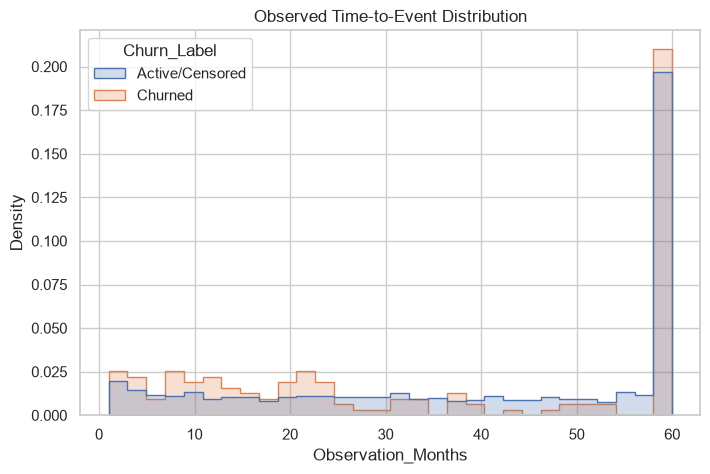

In [4]:
fig,ax=plt.subplots(figsize=(8,5))
sns.histplot(
    data=df,
    x="Observation_Months",
    hue="Churn_Label",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax
)
ax.set_title("Observed Time-to-Event Distribution")
save_plot("7-exploratory-analysis.png")
plt.show()

Saved: output/7-exploratory-analysis.png


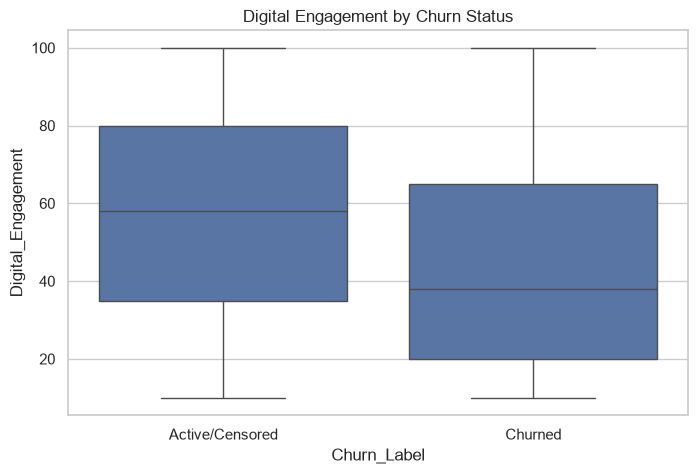

In [5]:
fig,ax=plt.subplots(figsize=(8,5))
sns.boxplot(data=df,x="Churn_Label",y="Digital_Engagement",ax=ax)
ax.set_title("Digital Engagement by Churn Status")
save_plot("7-exploratory-analysis.png")
plt.show()

## 8. Why Censoring Matters

Suppose we observe:

```text
Customer A → churned after 18 months
Customer B → active after 36 months
```

For Customer A:

```text
duration = 18
event = 1
```

For Customer B:

```text
duration = 36
event = 0
```

Customer B is not necessarily a "non-churner".

We simply did not observe the churn event during the available period.

This is why ordinary classification can lose important information.

## 9. Kaplan-Meier Estimator

The Kaplan-Meier curve estimates the probability of surviving (not churning) past each month directly from the data. Its strength is that it correctly handles censored customers who were still active when the data was extracted.


Saved: output/9-kaplan-meier-estimator.png


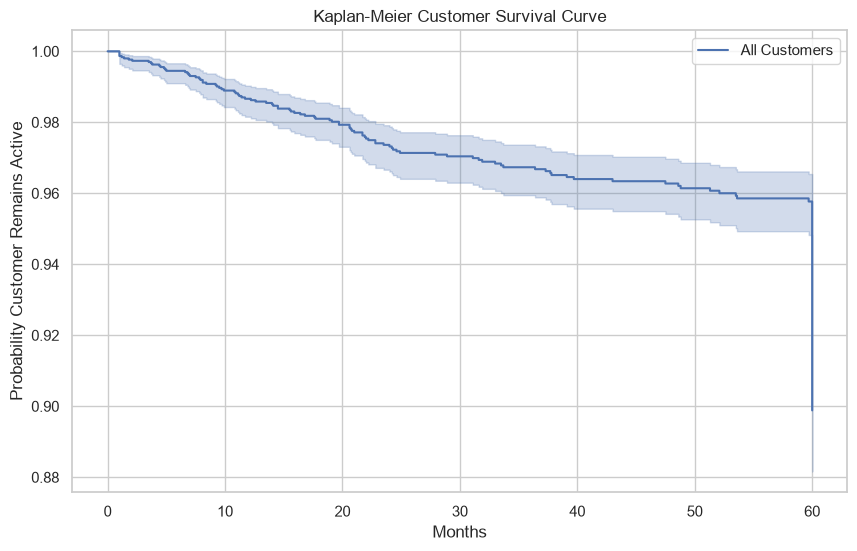

In [6]:
kmf=KaplanMeierFitter()

kmf.fit(
    durations=df["Observation_Months"],
    event_observed=df["Churn_Event"],
    label="All Customers"
)

fig,ax=plt.subplots(figsize=(10,6))
kmf.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier Customer Survival Curve")
ax.set_xlabel("Months")
ax.set_ylabel("Probability Customer Remains Active")
save_plot("9-kaplan-meier-estimator.png")
plt.show()

## 10. Interpreting the Survival Curve

The y-axis represents:

> Probability that a customer has **not yet churned** by time t.

Example:

```text
S(12) = 0.85
```

would mean approximately 85% of customers are estimated to remain active through month 12.

The exact values should be read from the fitted dataset/model, not assumed in advance.

In [7]:
for month in [6,12,24,36,48]:
    try:
        print(
            f"Survival at {month} months:",
            round(float(kmf.predict(month)),3)
        )
    except:
        pass

Survival at 6 months: 0.994
Survival at 12 months: 0.987
Survival at 24 months: 0.973
Survival at 36 months: 0.967
Survival at 48 months: 0.963


## 11. Median Survival Time

The median survival time is the time at which estimated survival reaches 50%.

If the curve never reaches 50%, the median survival time is not estimable from the observed data.

In [8]:
print("Median survival time:",kmf.median_survival_time_)

Median survival time: inf


## 12. Survival by Customer Segment

A major benefit of Survival Analysis is comparing groups.

Question:

> Do customer segments have different retention patterns?

We use separate Kaplan-Meier curves.

Saved: output/12-survival-by-customer-segment.png


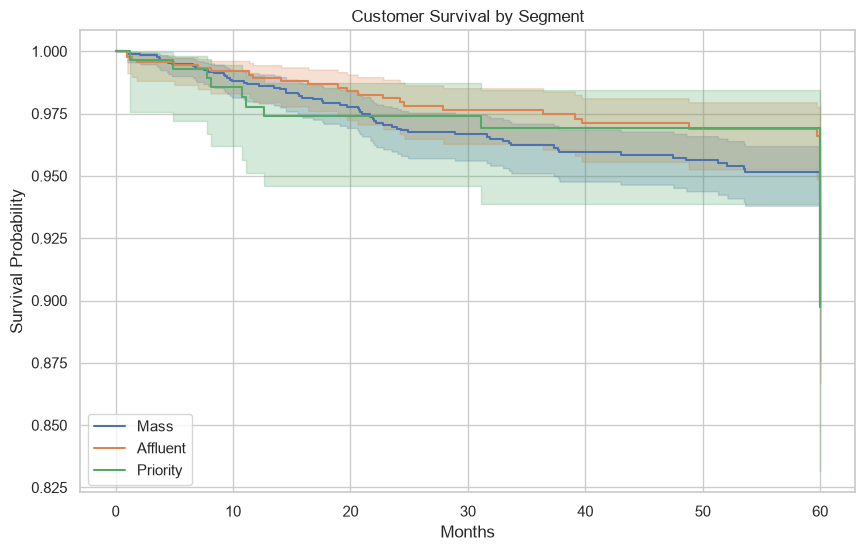

In [9]:
fig,ax=plt.subplots(figsize=(10,6))

for segment in df["Segment"].unique():
    subset=df[df["Segment"]==segment]
    fitter=KaplanMeierFitter()
    fitter.fit(
        subset["Observation_Months"],
        subset["Churn_Event"],
        label=segment
    )
    fitter.plot_survival_function(ax=ax)

ax.set_title("Customer Survival by Segment")
ax.set_xlabel("Months")
ax.set_ylabel("Survival Probability")
save_plot("12-survival-by-customer-segment.png")
plt.show()

## 13. Log-Rank Test

The log-rank test compares survival curves between groups.

For example:

```text
H0:
Survival distributions are the same.
```

A small p-value indicates evidence that the survival curves differ.

Statistical significance does not automatically mean the difference is operationally important.

In [10]:
mass=df[df["Segment"]=="Mass"]
affluent=df[df["Segment"]=="Affluent"]

test=logrank_test(
    mass["Observation_Months"],
    affluent["Observation_Months"],
    event_observed_A=mass["Churn_Event"],
    event_observed_B=affluent["Churn_Event"]
)

print("Test statistic:",round(test.test_statistic,3))
print("p-value:",test.p_value)

Test statistic: 0.55
p-value: 0.45850791057526874


## 14. Cox Proportional Hazards Model

The Cox model estimates how features affect **hazard**.

Conceptually:

```text
Hazard
=
instantaneous risk of event
given that the customer has survived until now
```

The model estimates a **hazard ratio (HR)**.

Interpretation:

```text
HR > 1 → higher hazard
HR < 1 → lower hazard
HR = 1 → no estimated association
```

This is an association model, not proof of causality.

## 15. Prepare Features for Cox Model

We use:

- Age
- Tenure
- Income
- Product count
- Transactions
- Digital engagement
- Complaints
- Credit utilization
- Late payments
- Segment

Customer_ID is excluded because it has no predictive meaning.

In [11]:
cox_df=df.drop(columns=["Customer_ID","Churn_Label"]).copy()

cox_df=pd.get_dummies(
    cox_df,
    columns=["Segment"],
    drop_first=True
)

cox_df=cox_df.astype(float)

display(cox_df.head())

,Age,Tenure_Months,Monthly_Income,Product_Count,Monthly_Transactions,Digital_Engagement,Complaint_Count,Credit_Utilization,Late_Payment_Count,Observation_Months,Churn_Event,Segment_Mass,Segment_Priority
0,25.0,94.0,26291033.0,1.0,18.0,15.0,1.0,0.539379,2.0,45.3,0.0,1.0,0.0
1,55.0,82.0,33851961.0,2.0,23.0,87.0,1.0,0.798801,1.0,60.0,0.0,1.0,0.0
2,50.0,112.0,27047010.0,2.0,21.0,98.0,1.0,0.846806,1.0,37.3,0.0,1.0,0.0
3,40.0,116.0,25387455.0,4.0,20.0,54.0,1.0,0.142273,0.0,60.0,0.0,1.0,0.0
4,40.0,86.0,20824887.0,2.0,9.0,25.0,4.0,0.831197,1.0,19.1,0.0,1.0,0.0


## 16. Train Cox Model

The Cox proportional-hazards model quantifies how each customer attribute multiplies the churn hazard while still respecting censored observations — the regression engine of survival analysis.


In [12]:
cph=CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="Observation_Months",
    event_col="Churn_Event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 3000 total observations, 2838 right-censored observations>
             duration col = 'Observation_Months'
                event col = 'Churn_Event'
      baseline estimation = breslow
   number of observations = 3000
number of events observed = 162
   partial log-likelihood = -1149.05
         time fit was run = 2026-09-23 02:59:39 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Age                  -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Tenure_Months        -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
Monthly_Income       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Product_Count        -0.27      0.76      0.07           -0.42           -0.13                0.66                0.88
Monthly_Transactions -0.01      0.99      0.02           -0.05            0.02                0.95                1.02
Digital_Engagement   -0.02      0.98      0.00           -0.03           -0.01                0.97                0.99
Complaint_Count       0.20      1.22      0.07            0.07            0.33                1.07                1.38
Credit_Utilization    1.62      5.05      0.32            0.99            2.25                2.68                9.52
Late_Payment_Count    0.14      1.15      0.09           -0.03            0.30                0.97                1.35
Segment_Mass          0.14      1.15      0.18           -0.21            0.49                0.81                1.64
Segment_Priority      0.13      1.14      0.29           -0.44            0.70                0.64                2.01

                      cmp to     z      p  -log2(p)
covariate                                          
Age                     0.00 -0.03   0.98      0.03
Tenure_Months           0.00 -3.68 <0.005     12.07
Monthly_Income          0.00 -1.21   0.23      2.14
Product_Count           0.00 -3.80 <0.005     12.74
Monthly_Transactions    0.00 -0.67   0.50      0.99
Digital_Engagement      0.00 -6.07 <0.005     29.58
Complaint_Count         0.00  2.99 <0.005      8.48
Credit_Utilization      0.00  5.01 <0.005     20.83
Late_Payment_Count      0.00  1.58   0.11      3.13
Segment_Mass            0.00  0.80   0.42      1.24
Segment_Priority        0.00  0.45   0.66      0.61
---
Concordance = 0.73
Partial AIC = 2320.11
log-likelihood ratio test = 103.45 on 11 df
-log2(p) of ll-ratio test = 54.59

## 17. Hazard Ratio Interpretation

Suppose a feature has:

```text
Hazard Ratio = 1.30
```

The model estimates a higher hazard associated with a one-unit increase in that feature, holding other included variables constant.

If:

```text
Hazard Ratio = 0.70
```

the estimated hazard is lower.

For continuous variables, the unit scale matters. Therefore, business interpretation should consider realistic changes rather than blindly interpreting a one-unit change.

In [13]:
hr=cph.summary[[
    "exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"
]].sort_values("exp(coef)",ascending=False)

hr.columns=["Hazard_Ratio","HR_Lower_95","HR_Upper_95","P_Value"]

display(hr.round(3))

,Hazard_Ratio,HR_Lower_95,HR_Upper_95,P_Value
covariate,,,,
Credit_Utilization,5.055,2.682,9.525,0.000
Complaint_Count,1.217,1.070,1.385,0.003
Segment_Mass,1.154,0.813,1.639,0.423
Late_Payment_Count,1.145,0.968,1.355,0.114
Segment_Priority,1.139,0.644,2.014,0.656
Monthly_Income,1.000,1.000,1.000,0.228
Age,1.000,0.988,1.012,0.977
Tenure_Months,0.991,0.987,0.996,0.000
Monthly_Transactions,0.988,0.953,1.024,0.504


## 18. Visualize Hazard Ratios

Hazard ratios are plotted with confidence intervals. Ratios above 1 raise churn risk, below 1 lower it, giving business owners an intuitive read of which drivers matter and how certain the effect is.


Saved: output/18-visualize-hazard-ratios.png


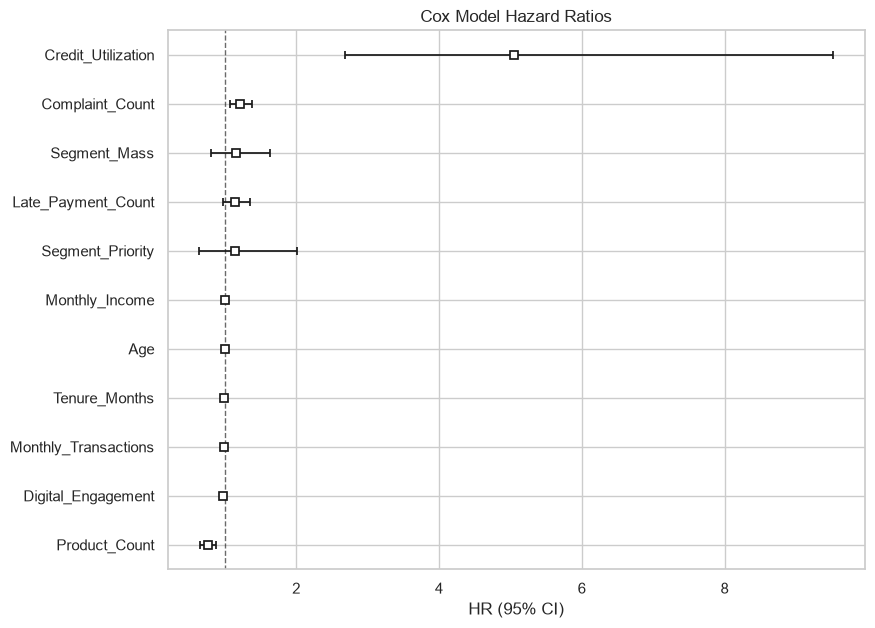

In [14]:
fig,ax=plt.subplots(figsize=(9,7))
cph.plot(hazard_ratios=True,ax=ax)
ax.set_title("Cox Model Hazard Ratios")
save_plot("18-visualize-hazard-ratios.png")
plt.show()

## 19. Proportional Hazards Assumption

The Cox model assumes that the hazard ratio between groups is approximately constant over time.

This assumption should be checked before production use.

Violation of the assumption can require:

- time-varying covariates,
- stratification,
- alternative survival models.

In [15]:
# Diagnostic check
# lifelines provides a built-in diagnostic.
# It may print warnings for variables that violate the assumption.
cph.check_assumptions(
    cox_df,
    p_value_threshold=0.05,
    show_plots=False
)

Proportional hazard assumption looks okay.


[]

## 20. Individual Survival Prediction

Once fitted, the Cox model can estimate a survival curve for an individual customer.

This answers:

> "Given this customer's characteristics, how does their estimated probability of remaining active change over time?" 

Saved: output/20-individual-survival-prediction.png


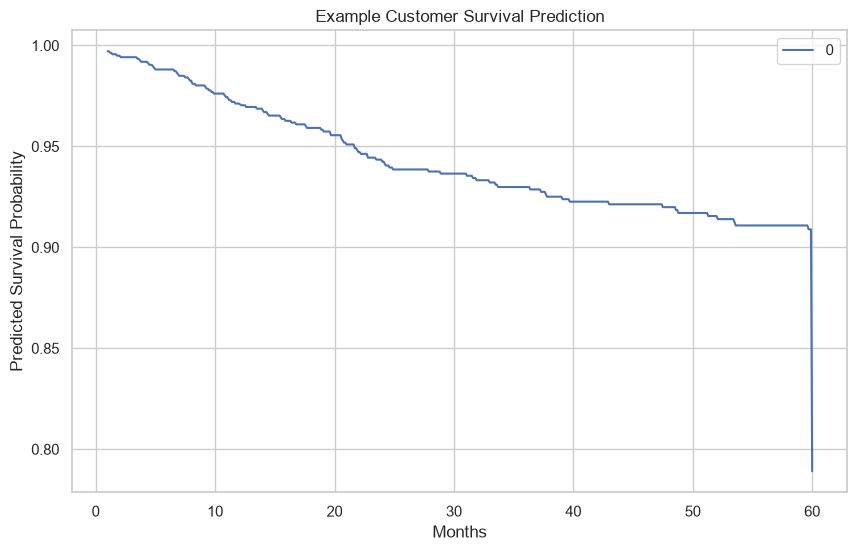

In [16]:
customer=cox_df.iloc[[0]].drop(columns=["Churn_Event","Observation_Months"])

survival_curve=cph.predict_survival_function(customer)

fig,ax=plt.subplots(figsize=(10,6))
survival_curve.plot(ax=ax)
ax.set_title("Example Customer Survival Prediction")
ax.set_xlabel("Months")
ax.set_ylabel("Predicted Survival Probability")
save_plot("20-individual-survival-prediction.png")
plt.show()

## 21. Predicted Churn Risk at a Specific Horizon

Instead of predicting only:

```text
Churn = Yes / No
```

we can ask:

```text
Probability of surviving 12 months?
Probability of surviving 24 months?
```

Therefore:

```text
Churn Risk at 12 months
= 1 - Survival Probability at 12 months
```

In [17]:
predicted_survival=cph.predict_survival_function(
    cox_df.drop(columns=["Churn_Event","Observation_Months"])
)

horizons=[6,12,24,36]

risk_table=pd.DataFrame(index=range(len(df)))

for h in horizons:
    survival_at_h=predicted_survival.iloc[
        predicted_survival.index.get_indexer([h],method="nearest")[0]
    ]
    risk_table[f"Churn_Risk_{h}M"]=1-survival_at_h.values

display(risk_table.head().round(3))

,Churn_Risk_6M,Churn_Risk_12M,Churn_Risk_24M,Churn_Risk_36M
0,0.012,0.029,0.058,0.070
1,0.003,0.007,0.014,0.018
2,0.002,0.005,0.011,0.013
3,0.001,0.002,0.004,0.005
4,0.024,0.057,0.111,0.135


## 22. Customer Risk Segmentation

A survival model can support operational segmentation:

```text
Low estimated churn risk
        ↓
Normal engagement

Medium risk
        ↓
Targeted retention

High risk
        ↓
Retention intervention
```

The threshold should be selected using business costs, capacity, validation data, and policy—not arbitrarily.

In [18]:
risk_12=risk_table["Churn_Risk_12M"]

risk_segment=pd.cut(
    risk_12,
    bins=[-np.inf,.25,.50,np.inf],
    labels=["Low","Medium","High"]
)

risk_summary=pd.DataFrame({
    "Customer_ID":df["Customer_ID"],
    "Risk_12M":risk_12,
    "Risk_Band":risk_segment
})

display(risk_summary.head(20))
display(risk_summary["Risk_Band"].value_counts().to_frame("Customers"))

,Customer_ID,Risk_12M,Risk_Band
0,C00001,0.028799,Low
1,C00002,0.007177,Low
2,C00003,0.005280,Low
3,C00004,0.001965,Low
4,C00005,0.056574,Low
5,C00006,0.031933,Low
6,C00007,0.008612,Low
7,C00008,0.005318,Low
8,C00009,0.008736,Low
9,C00010,0.019792,Low


,Customers
Risk_Band,
Low,3000
Medium,0
High,0


## 23. Survival Analysis vs Classification

| Classification | Survival Analysis |
|---|---|
| Churn yes/no | Churn + timing |
| Often ignores censoring | Explicitly handles censoring |
| Fixed prediction horizon | Multiple horizons |
| Probability of class | Survival / hazard estimates |
| "Will churn?" | "When might churn occur?" |

Both can be useful.

The correct choice depends on the business question.

## 24. Survival Analysis vs Forecasting

Forecasting:

```text
What will aggregate demand be next month?
```

Survival Analysis:

```text
When will this customer churn?
```

Forecasting generally models a time series or aggregate future values.

Survival Analysis models **time-to-event at the individual or cohort level**.

## 25. Business Use Case — Retention

A possible workflow:

```text
Customer Base
      ↓
Survival Model
      ↓
12M Churn Risk
      +
Expected Timing
      ↓
Customer Prioritization
      ↓
Retention Campaign
      ↓
Customer Response
      ↓
Measure Outcome
```

The model identifies risk; the retention strategy should be evaluated separately.

## 26. Alternative Use Case — Loan Default Timing

The same methodology can be applied to loans.

Replace:

```text
Customer Churn
```

with:

```text
Loan Default
```

Then:

```text
Duration = Months Since Loan Origination
Event = Default
Censoring = Loan Still Performing at Observation End
```

Potential features:

- DPD history
- utilization
- income
- outstanding balance
- payment ratio
- loan age
- customer tenure.

## 27. Model Evaluation

For Survival Analysis, conventional accuracy is usually not enough.

Common metrics include:

### Concordance Index (C-index)

Measures whether higher predicted risk tends to correspond to earlier events.

### Brier Score

Measures prediction error over time.

### Calibration

Checks whether predicted survival/risk aligns with observed outcomes.

### Time-dependent AUC

Evaluates discrimination at specific time horizons.

In [19]:
print("Cox concordance index:",round(cph.concordance_index_,3))

Cox concordance index: 0.732


## 28. Common Mistakes

1. Treating censored customers as non-churners.
2. Ignoring observation duration.
3. Using future information as a feature.
4. Confusing hazard with probability.
5. Interpreting correlation as causation.
6. Ignoring proportional hazards assumptions.
7. Evaluating only one time horizon.
8. Using arbitrary risk thresholds.
9. Ignoring calibration.
10. Deploying without monitoring.

## 29. Production Architecture

```text
Customer / Loan Data
        ↓
Feature Engineering
        ↓
Survival Model
        ↓
Risk at 3 / 6 / 12 / 24 Months
        ↓
Customer / Loan Prioritization
        ↓
CRM / Collection / Retention
        ↓
Outcome Tracking
        ↓
Model Monitoring
        ↓
Retraining
```

For banking production systems, add:

- model governance,
- audit trails,
- data quality checks,
- access control,
- explainability,
- monitoring,
- champion/challenger validation.

## 30. Final Executive Summary

### Business Question

> **When is the customer likely to churn?**

### Solution

```text
Customer Data
     ↓
Survival Analysis
     ↓
Kaplan-Meier
     ↓
Cox Proportional Hazards
     ↓
Survival Probability
     +
Churn Risk
     +
Timing
```

### Key Advantage

Instead of only saying:

```text
Customer A → Churn = Yes
```

we can estimate:

```text
Customer A
→ estimated survival probability over time
→ estimated churn risk at specific horizons
→ relative risk factors
```

### Banking Applications

- Customer churn timing
- Loan default timing
- Credit card cancellation
- Product retention
- Delinquency timing
- Collection prioritization

> **Survival Analysis is especially useful when the timing of an event is as important as whether the event happens.**

## 31. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [20]:
hr.to_csv(OUTPUT_DIR / "cox_hazard_ratios.csv", index=False)
print("Saved:", OUTPUT_DIR / "cox_hazard_ratios.csv")
predicted_survival.to_csv(OUTPUT_DIR / "predicted_survival_function_sample.csv", index=False)
print("Saved:", OUTPUT_DIR / "predicted_survival_function_sample.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/cox_hazard_ratios.csv


Saved: output/predicted_survival_function_sample.csv
  output/12-survival-by-customer-segment.png
  output/18-visualize-hazard-ratios.png
  output/20-individual-survival-prediction.png
  output/7-exploratory-analysis.png
  output/9-kaplan-meier-estimator.png
  output/cox_hazard_ratios.csv
  output/predicted_survival_function_sample.csv
